# CISI Band Ratio Graphs — Frequency Domain and Time-Frequency Domain

This notebook uses the same overall method as your global-baseline notebook, but instead of graphing individual band power, it graphs **ratios between pairs of frequency bands**.

For the frequency-domain ratio graphs:

1. Load the same CISI epochs.
2. Optionally crop to a specific time window.
3. Compute frequency-domain absolute power with `compute_frequency_power()`.
4. Convert the output into a trial × band table.
5. Compute ratios such as `theta / delta`.
6. Subtract each subject's global mean ratio across trials.
7. Grand-average the centered ratios across subjects.
8. Plot each ratio across trial index with SEM shading and a rolling mean.

For the time-frequency ratio graphs:

1. Load the same CISI epochs.
2. Compute Morlet time-frequency power using the same settings as your original notebook.
3. Collapse frequencies into delta, theta, alpha, beta, and gamma bands.
4. Compute ratio maps such as `theta / delta` at each trial × time point.
5. Subtract each subject's global mean ratio across all trials and all time points.
6. Grand-average the centered ratio time courses across subjects.
7. Plot each ratio across time.


> Note: This CISI copy was converted from the CISI notebook by changing CISI labels, condition names, channel labels, and output filenames to CISI. The time windows were kept the same as the CISI notebook for now (`0–500 ms` and `500–1000 ms`). If CISI uses different event timing, update the `tmin`/`tmax` values in the window-specific cells before running those sections.


In [1]:

# NumPy handles arrays, indexing, and mathematical operations.
import numpy as np

# Pandas stores trial-by-band tables and makes averaging easier.
import pandas as pd

# Matplotlib is used to make the figures.
import matplotlib.pyplot as plt

# These imports let us silence extra warnings / printouts from the helper functions.
import warnings
import contextlib
import io

# These project helper functions are already used elsewhere in your notebook.
# - load_eeg_data loads the epochs for one subject
# - compute_frequency_power computes frequency-domain band power per trial
from utils import load_eeg_data, compute_frequency_power

# Show plots directly inside the notebook.
%matplotlib inline

# Slightly increase default display quality so the plots are easier to read.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


In [2]:

# These are the subjects used in your CISI analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
# For CISI, the working notebook loads the data using the P1 condition label.
CONDITION = "P1"

# CHANNELS tells the loader which ROI channel group to use.
# For CISI, the working notebook also uses the P1 channel label.
CHANNELS = "P1"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


# ------------------------------------------------------------
# BAND RATIO SETTINGS
# ------------------------------------------------------------

# Each tuple is written as:
#     ('numerator_band', 'denominator_band')
#
# Example:
#     ('theta', 'alpha') means theta power divided by alpha power.
#
# You can edit this list if you want different pairs.
BAND_RATIO_PAIRS = [
    ('theta', 'delta'),
    ('alpha', 'theta'),
    ('beta', 'alpha'),
    ('gamma', 'beta'),
    ('theta', 'beta'),
    ('gamma', 'theta'),
    ('gamma', 'alpha')
]

# These labels will be used on the plots.
ratio_labels = [f"{num}/{den}" for num, den in BAND_RATIO_PAIRS]

# Colors for ratio plots. If there are more ratios than colors, the list repeats.
ratio_colors = [
    'blue',
    'green',
    'red',
    'orange',
    'purple',
    'brown',
    'pink',
    'gray',
    'olive',
    'cyan'
]

print("Band ratio pairs:")
for pair in BAND_RATIO_PAIRS:
    print(f"  {pair[0]} / {pair[1]}")


Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: P1
Channels: P1
Baseline definition: global average over all times and all trials
Band ratio pairs:
  theta / delta
  alpha / theta
  beta / alpha
  gamma / beta
  theta / beta
  gamma / theta
  gamma / alpha


In [3]:
# Safety imports so this cell still works if the import cell was not run first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import contextlib
import io
from utils import load_eeg_data, compute_frequency_power


# ------------------------------------------------------------
# HELPER FUNCTION: COMPUTE CENTERED BAND RATIOS
# ------------------------------------------------------------

def compute_centered_band_ratios_for_window(window_name, tmin=None, tmax=None):
    """
    Computes centered frequency-band ratios for one time window.

    Parameters
    ----------
    window_name : str
        Text label for the window, such as "all_times", "0_500", or "500_1000".

    tmin : float or None
        Start time in seconds.
        Use None to keep the original beginning of the epoch.

    tmax : float or None
        End time in seconds.
        Use None to keep the original end of the epoch.

    Returns
    -------
    results : dict
        A dictionary containing raw ratio tables, baseline ratio tables,
        centered ratio tables, grand averages, SEMs, processed subjects,
        and failed subjects.
    """

    # These dictionaries store subject-level results.
    all_power_pivots_raw = {}
    all_ratio_pivots_raw = {}
    all_ratio_baseline_pivots = {}
    all_ratio_pivots_centered = {}
    all_psds_dicts = {}

    processed_subjects_window = []
    failed_subjects_window = []

    # Loop through each subject.
    for subject_id in SUBJECTS:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                    # Load the same CISI/P1 epochs as the original notebook.
                    epochs = load_eeg_data(
                        CONDITION,
                        subject_id,
                        channels=CHANNELS,
                        freq_band="delta_gamma"
                    )

                    # Crop only if a time window was given.
                    # MNE uses seconds, so:
                    #   0–500 ms      = tmin=0.0, tmax=0.5
                    #   500–1000 ms   = tmin=0.5, tmax=1.0
                    if tmin is not None or tmax is not None:
                        epochs_for_ratio = epochs.copy().crop(tmin=tmin, tmax=tmax)
                    else:
                        epochs_for_ratio = epochs.copy()

                    # Compute frequency-domain absolute power using the same helper function.
                    power_df, psds_dict = compute_frequency_power(
                        epochs_for_ratio,
                        fmin=0.5,
                        fmax=45
                    )

            # Convert long-format power output into trial x band format.
            power_pivot_raw = (
                power_df.groupby(['trial', 'band'])['power']
                .mean()
                .unstack()
                .reindex(columns=bands)
            )

            # This table will hold ratio values for each trial.
            ratio_pivot_raw = pd.DataFrame(index=power_pivot_raw.index)

            # Compute each requested band ratio.
            for numerator_band, denominator_band in BAND_RATIO_PAIRS:

                ratio_name = f"{numerator_band}/{denominator_band}"

                # Make sure both bands exist before computing the ratio.
                if numerator_band in power_pivot_raw.columns and denominator_band in power_pivot_raw.columns:

                    # Ratio = power in numerator band / power in denominator band.
                    ratio_pivot_raw[ratio_name] = (
                        power_pivot_raw[numerator_band] / power_pivot_raw[denominator_band]
                    )

                else:
                    # If a band is missing, fill with NaN so the notebook does not crash.
                    ratio_pivot_raw[ratio_name] = np.nan

            # Replace infinite values with NaN, just in case a denominator is zero.
            ratio_pivot_raw = ratio_pivot_raw.replace([np.inf, -np.inf], np.nan)

            # Compute this subject's global mean ratio across all trials.
            ratio_global_baseline = ratio_pivot_raw.mean(axis=0)

            # Center each trial by subtracting this subject's global mean ratio.
            ratio_pivot_centered = ratio_pivot_raw - ratio_global_baseline

            # Store subject-level outputs.
            all_power_pivots_raw[subject_id] = power_pivot_raw
            all_ratio_pivots_raw[subject_id] = ratio_pivot_raw
            all_ratio_baseline_pivots[subject_id] = pd.DataFrame(
                [ratio_global_baseline],
                columns=ratio_pivot_raw.columns
            )
            all_ratio_pivots_centered[subject_id] = ratio_pivot_centered
            all_psds_dicts[subject_id] = psds_dict

            processed_subjects_window.append(subject_id)

        except Exception as e:
            failed_subjects_window.append((subject_id, str(e)))

    print(f"{window_name} ratio subjects processed:", processed_subjects_window)

    if failed_subjects_window:
        print(f"\n{window_name} ratio failures:")
        for subject_id, err in failed_subjects_window:
            print(f"Subject {subject_id}: {err}")

    # Grand average across subjects.
    grand_ratio = {}
    grand_ratio_sem = {}

    for ratio_name in ratio_labels:
        ratio_trials = []

        for subject_id in processed_subjects_window:
            ratio_pivot = all_ratio_pivots_centered[subject_id]

            if ratio_name in ratio_pivot.columns:
                ratio_trials.append(ratio_pivot[ratio_name].reset_index(drop=True))

        if ratio_trials:
            ratio_df = pd.concat(ratio_trials, axis=1)

            # Mean across subjects at each trial index.
            grand_ratio[ratio_name] = ratio_df.mean(axis=1)

            # SEM across subjects at each trial index.
            grand_ratio_sem[ratio_name] = ratio_df.std(axis=1) / np.sqrt(ratio_df.shape[1])

    return {
        "window_name": window_name,
        "tmin": tmin,
        "tmax": tmax,
        "all_power_pivots_raw": all_power_pivots_raw,
        "all_ratio_pivots_raw": all_ratio_pivots_raw,
        "all_ratio_baseline_pivots": all_ratio_baseline_pivots,
        "all_ratio_pivots_centered": all_ratio_pivots_centered,
        "all_psds_dicts": all_psds_dicts,
        "processed_subjects": processed_subjects_window,
        "failed_subjects": failed_subjects_window,
        "grand_ratio": grand_ratio,
        "grand_ratio_sem": grand_ratio_sem
    }


# ------------------------------------------------------------
# HELPER FUNCTION: PLOT CENTERED BAND RATIOS
# ------------------------------------------------------------

def plot_centered_band_ratios(results, title_label, save_filename):
    """
    Plots the grand-average centered ratio values for one time window.

    Parameters
    ----------
    results : dict
        Output from compute_centered_band_ratios_for_window().

    title_label : str
        Label used in the graph title, such as "All Times" or "0–500 ms".

    save_filename : str
        Name of the saved PNG file.
    """

    grand_ratio = results["grand_ratio"]
    grand_ratio_sem = results["grand_ratio_sem"]

    # Create one subplot per ratio.
    fig, axes = plt.subplots(len(ratio_labels), 1, figsize=(12, 2.5 * len(ratio_labels)), sharex=True)

    # If there is only one ratio, axes is not automatically a list.
    # This forces it to act like a list so the loop below still works.
    if len(ratio_labels) == 1:
        axes = [axes]

    for i, ratio_name in enumerate(ratio_labels):
        ax = axes[i]
        color = ratio_colors[i % len(ratio_colors)]

        if ratio_name in grand_ratio:
            values = grand_ratio[ratio_name].values
            errors = grand_ratio_sem[ratio_name].values
            trial_idx = np.arange(1, len(values) + 1)

            ax.scatter(
                trial_idx,
                values,
                color=color,
                s=20,
                alpha=0.55,
                zorder=2,
                label='Trial value'
            )

            ax.plot(
                trial_idx,
                values,
                color=color,
                linewidth=0.7,
                alpha=0.35,
                zorder=1
            )

            ax.fill_between(
                trial_idx,
                values - errors,
                values + errors,
                color=color,
                alpha=0.18,
                zorder=1,
                label='± SEM'
            )

            rolling = pd.Series(values).rolling(
                window=ROLLING_WINDOW,
                center=True,
                min_periods=1
            ).mean()

            ax.plot(
                trial_idx,
                rolling,
                color='black',
                linewidth=2.5,
                zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})'
            )

        ax.set_ylabel('Ratio minus\nglobal mean', fontsize=10)

        ax.set_title(
            f'ROI average — {ratio_name} ratio, {title_label}',
            fontsize=10,
            fontweight='bold'
        )

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.25)
        ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel('Trial index', fontsize=11)

    fig.suptitle(
        f'CISI Protocol — Grand Average Frequency-Domain Band Ratios, {title_label}\n'
        f'Centered to subject-level global ratio average',
        fontsize=12,
        fontweight='bold'
    )

    fig.tight_layout()
    plt.savefig(save_filename, bbox_inches='tight', dpi=150)
    plt.show()

    print(f"Figure saved: {save_filename}")


all_times ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


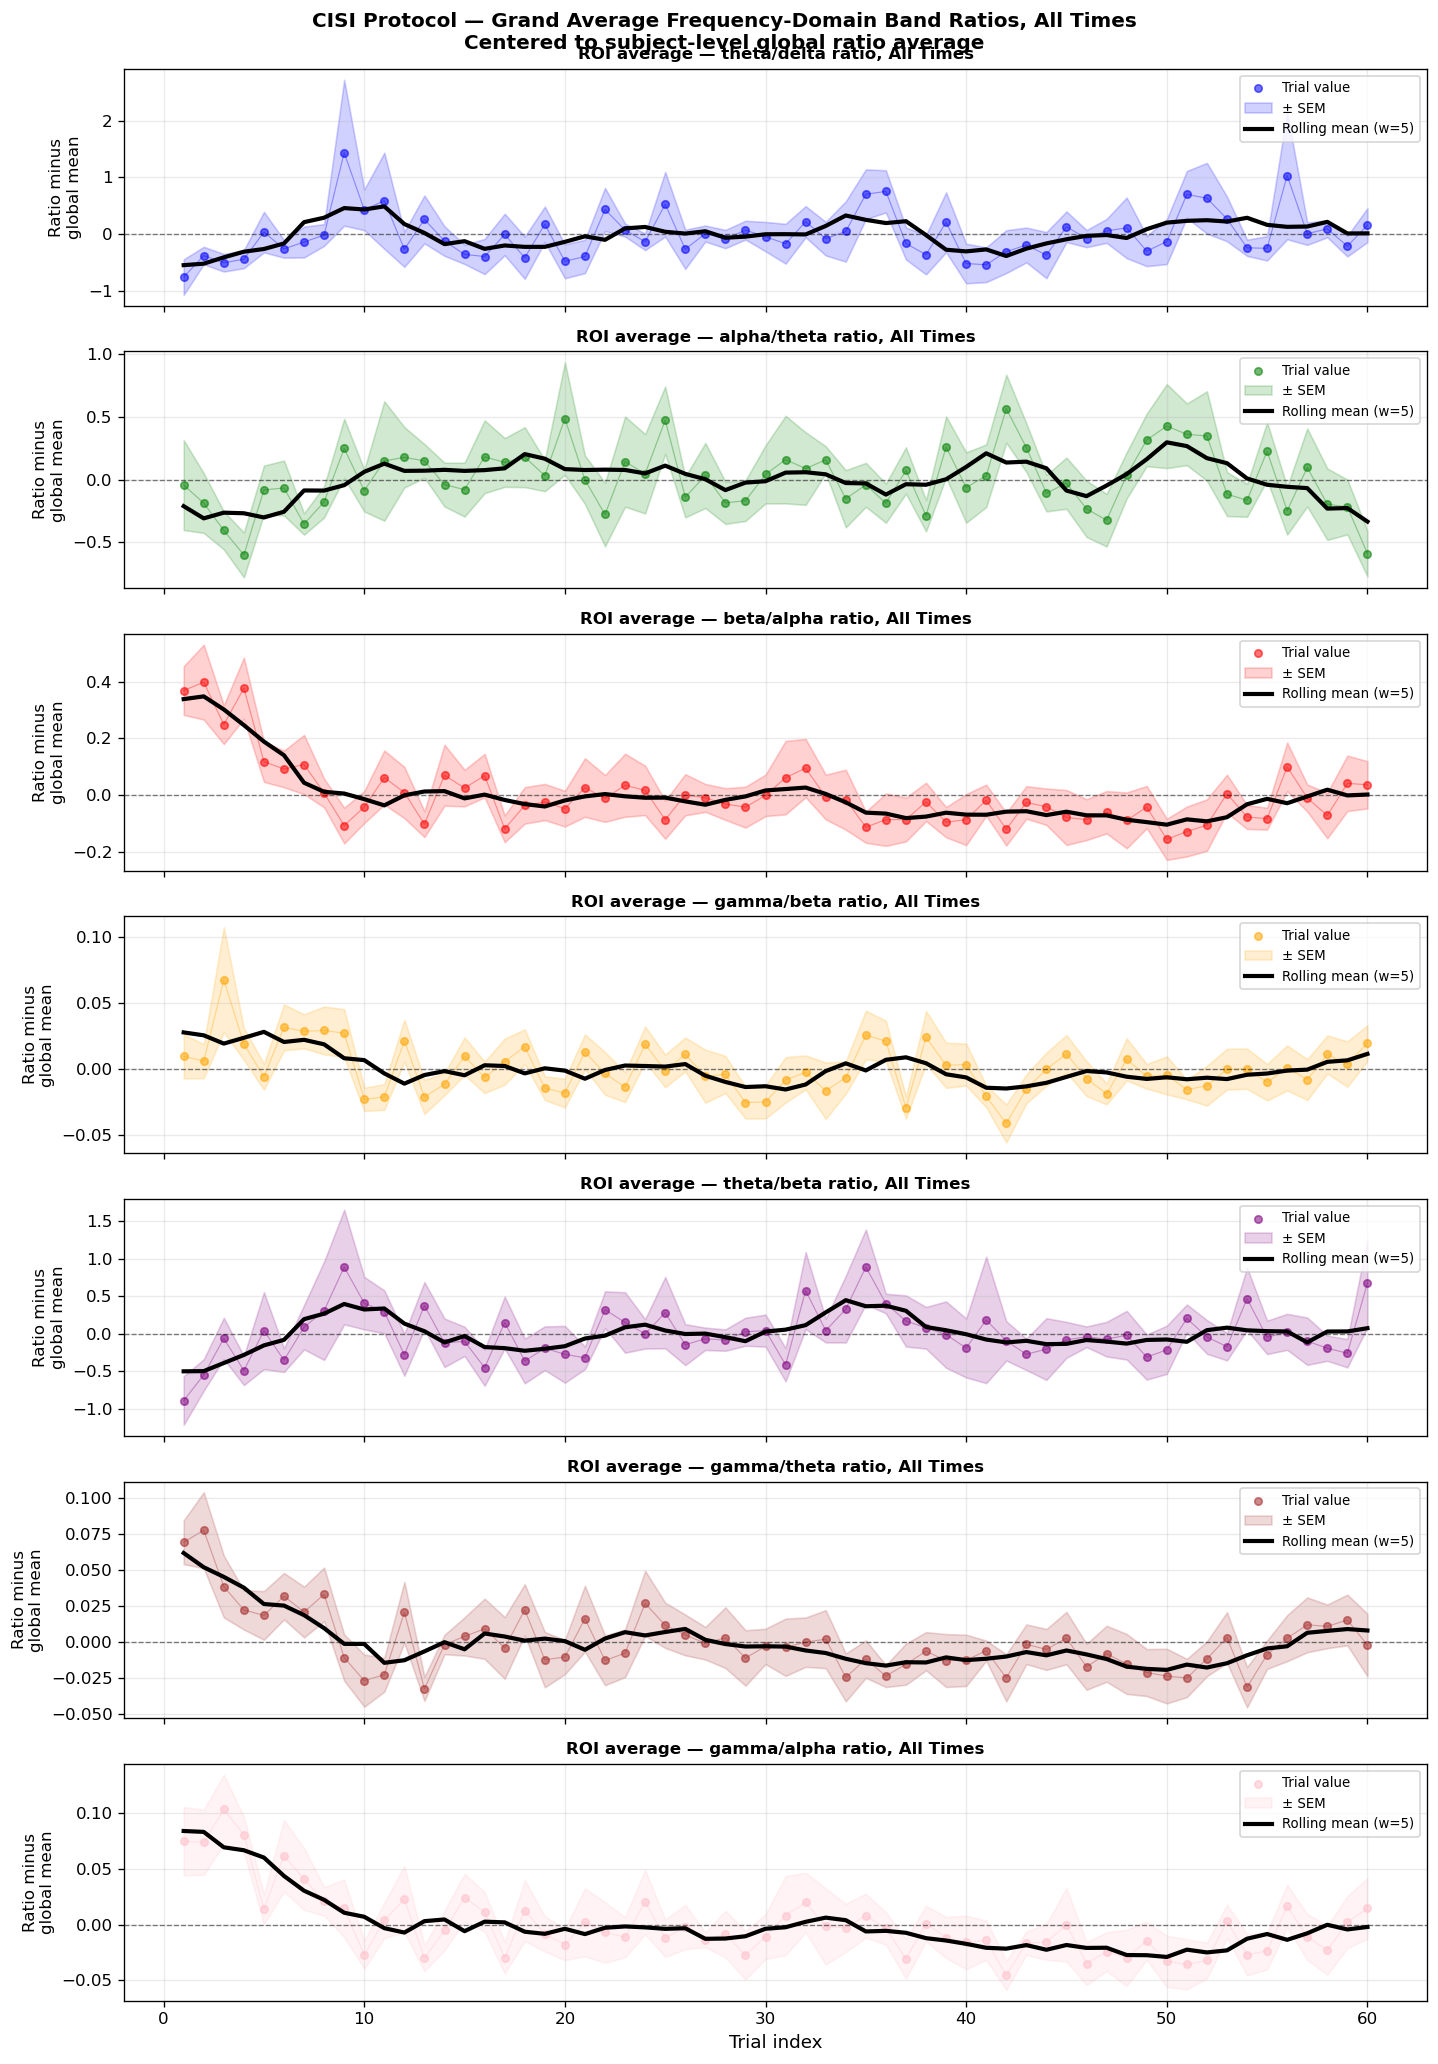

Figure saved: CISI_band_ratios_all_times_global_mean_centered.png


In [4]:

# ------------------------------------------------------------
# BAND RATIOS — ALL TIMES
# ------------------------------------------------------------

ratio_results_all_times = compute_centered_band_ratios_for_window(
    window_name="all_times",
    tmin=None,
    tmax=None
)

plot_centered_band_ratios(
    results=ratio_results_all_times,
    title_label="All Times",
    save_filename="CISI_band_ratios_all_times_global_mean_centered.png"
)


neg500_0_ms ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


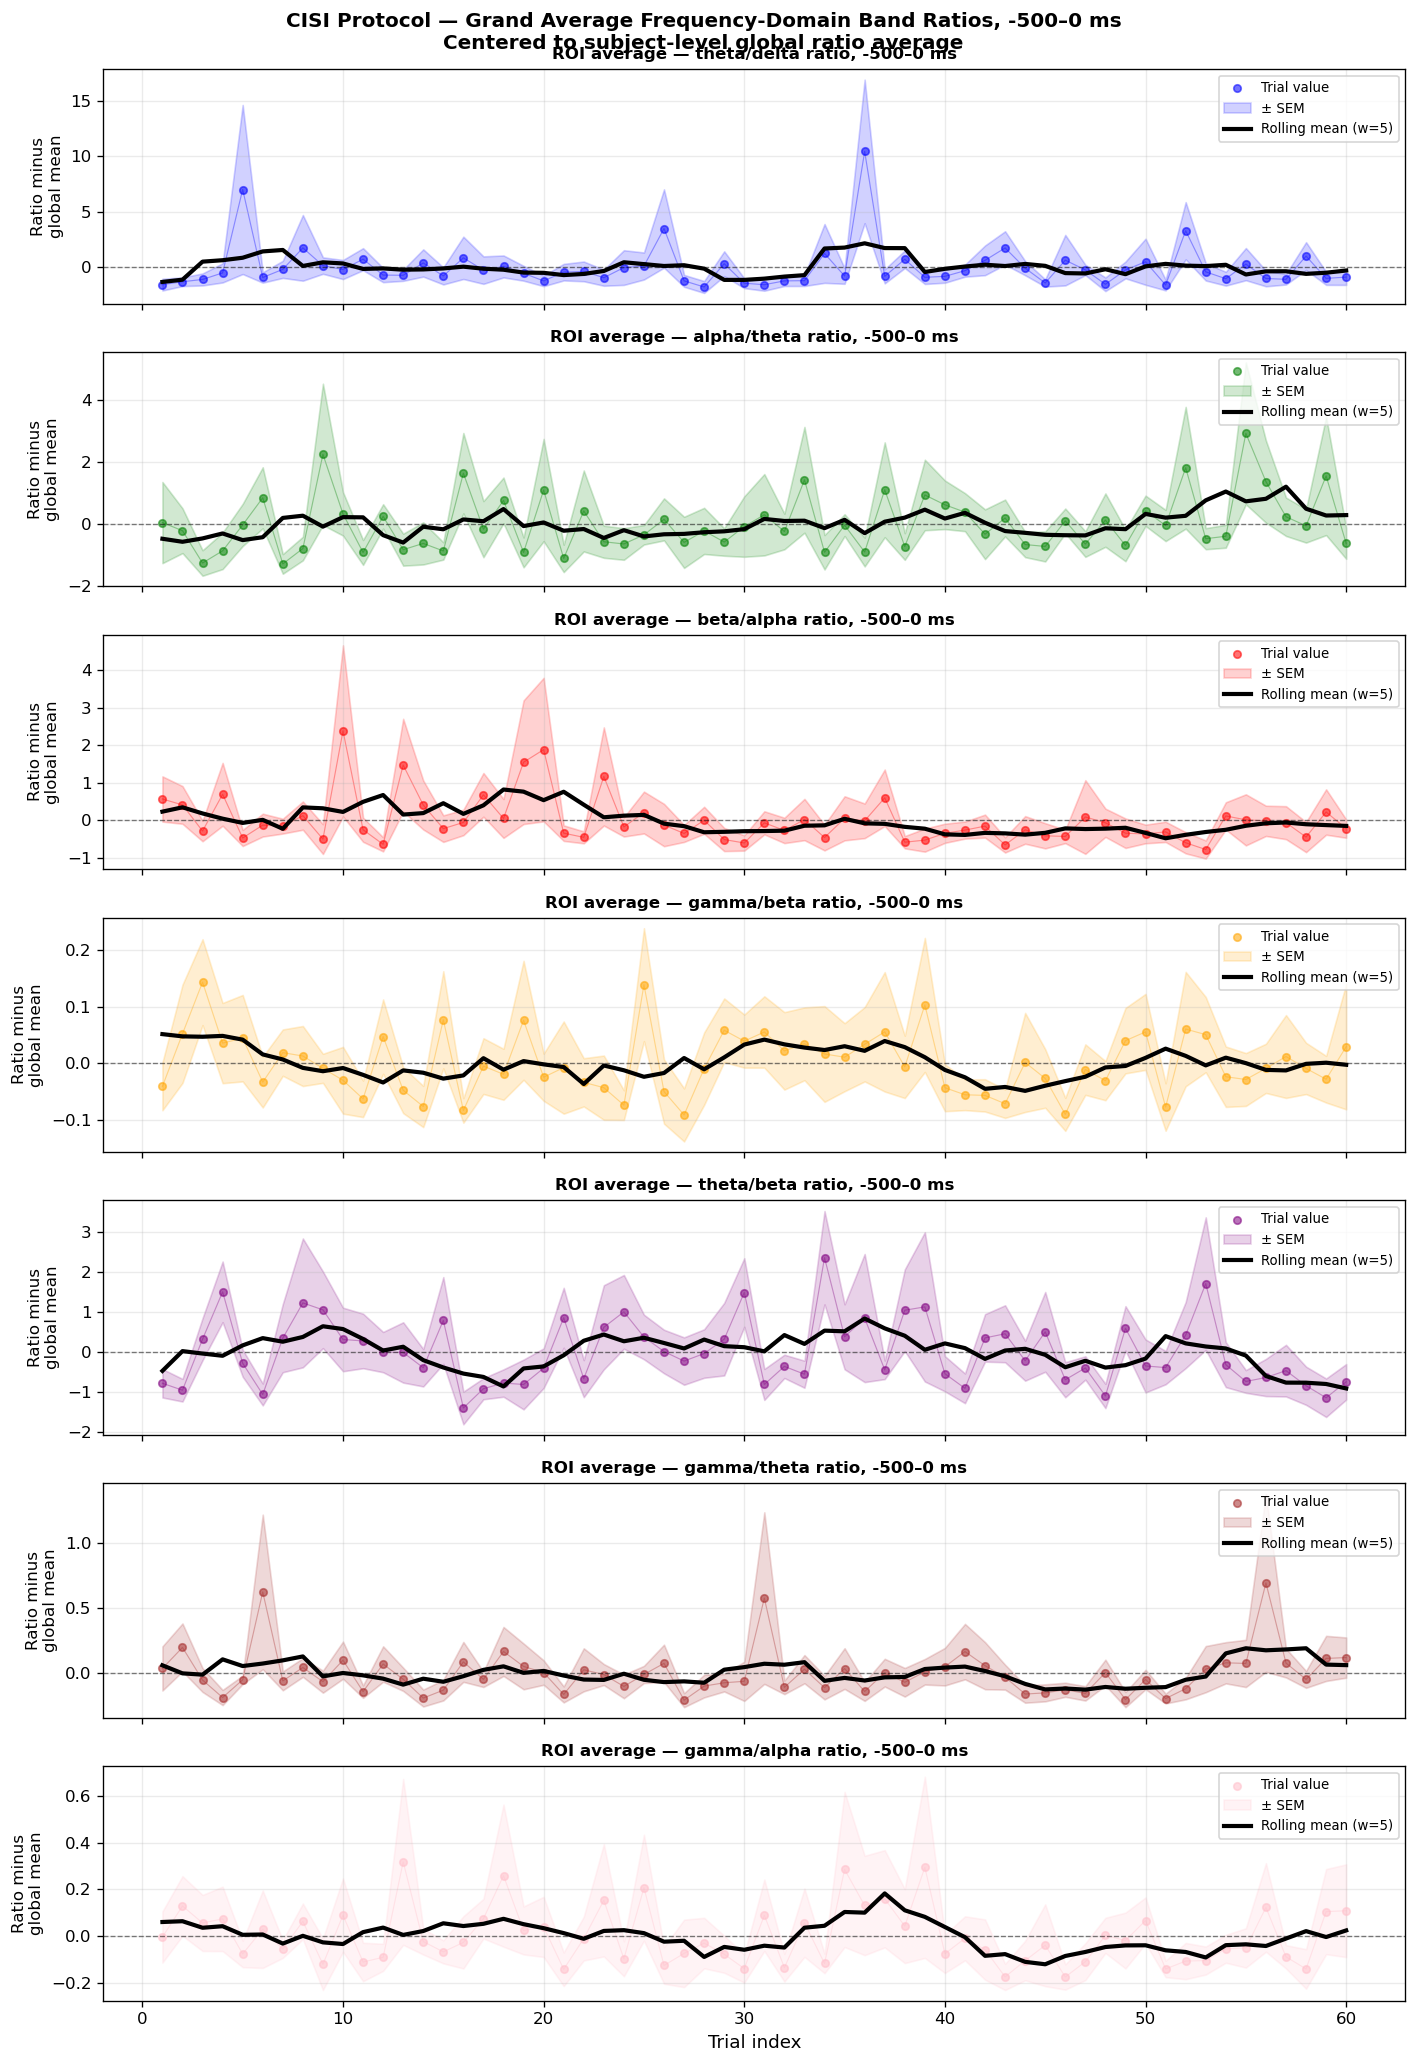

Figure saved: CISI_band_ratios_neg500_0_global_mean_centered.png


In [5]:

# ------------------------------------------------------------
# BAND RATIOS — -500–0 ms
# ------------------------------------------------------------

ratio_results_neg500_0 = compute_centered_band_ratios_for_window(
    window_name="neg500_0_ms",
    tmin=-0.5,
    tmax=0.0
)

plot_centered_band_ratios(
    results=ratio_results_neg500_0,
    title_label="-500–0 ms",
    save_filename="CISI_band_ratios_neg500_0_global_mean_centered.png"
)


0_500_ms ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


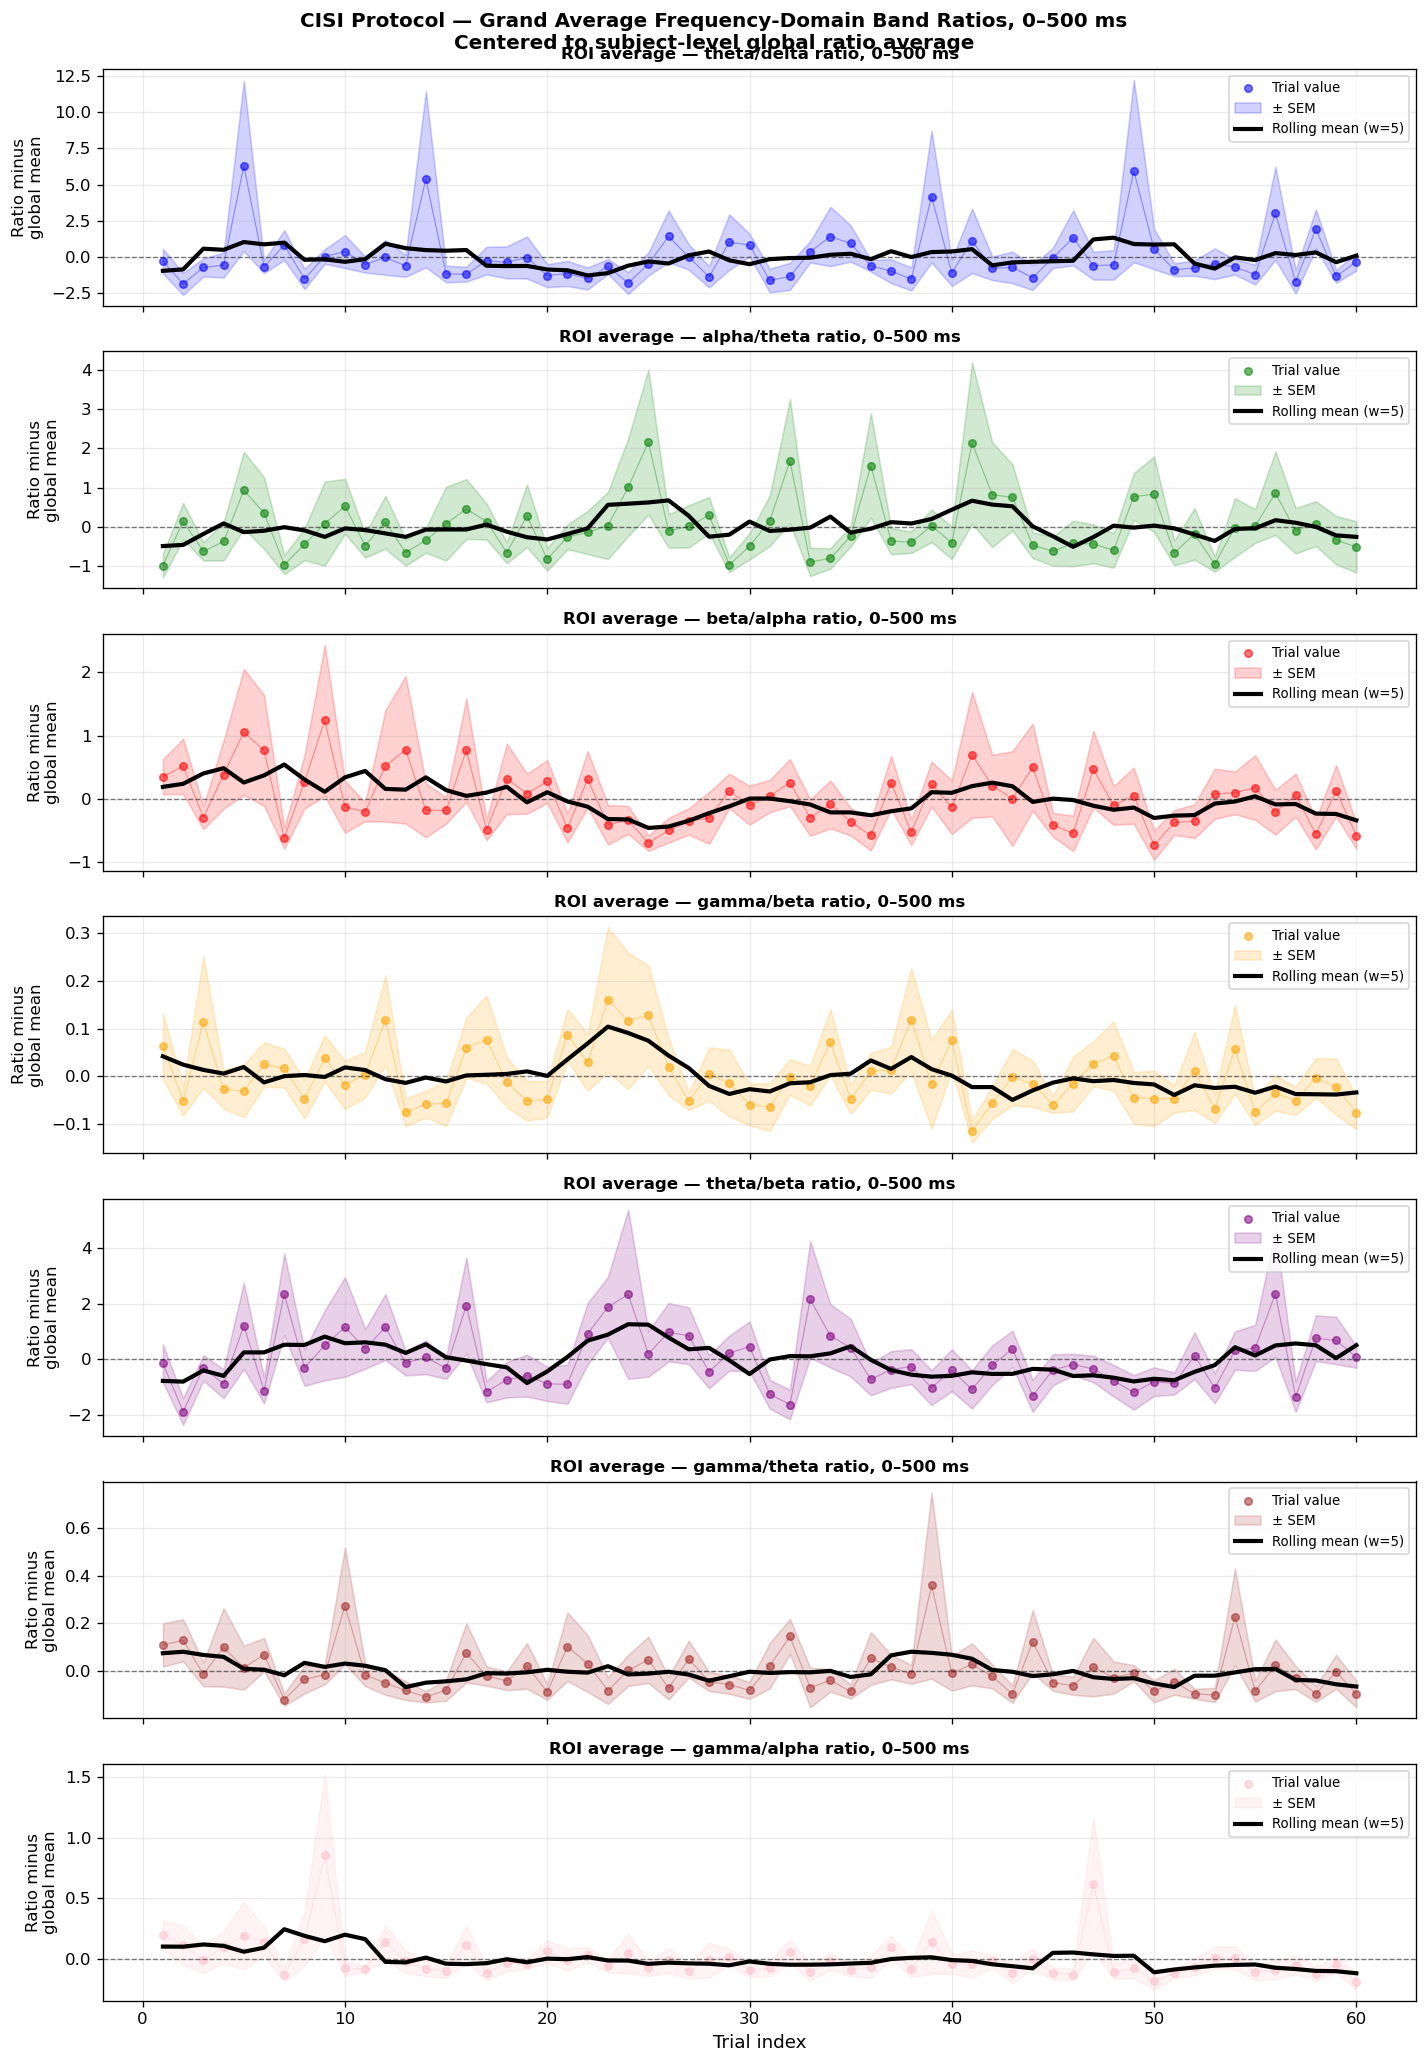

Figure saved: CISI_band_ratios_0_500_global_mean_centered.png


In [6]:

# ------------------------------------------------------------
# BAND RATIOS — 0–500 ms
# ------------------------------------------------------------

ratio_results_0_500 = compute_centered_band_ratios_for_window(
    window_name="0_500_ms",
    tmin=0.0,
    tmax=0.5
)

plot_centered_band_ratios(
    results=ratio_results_0_500,
    title_label="0–500 ms",
    save_filename="CISI_band_ratios_0_500_global_mean_centered.png"
)


500_1000_ms ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


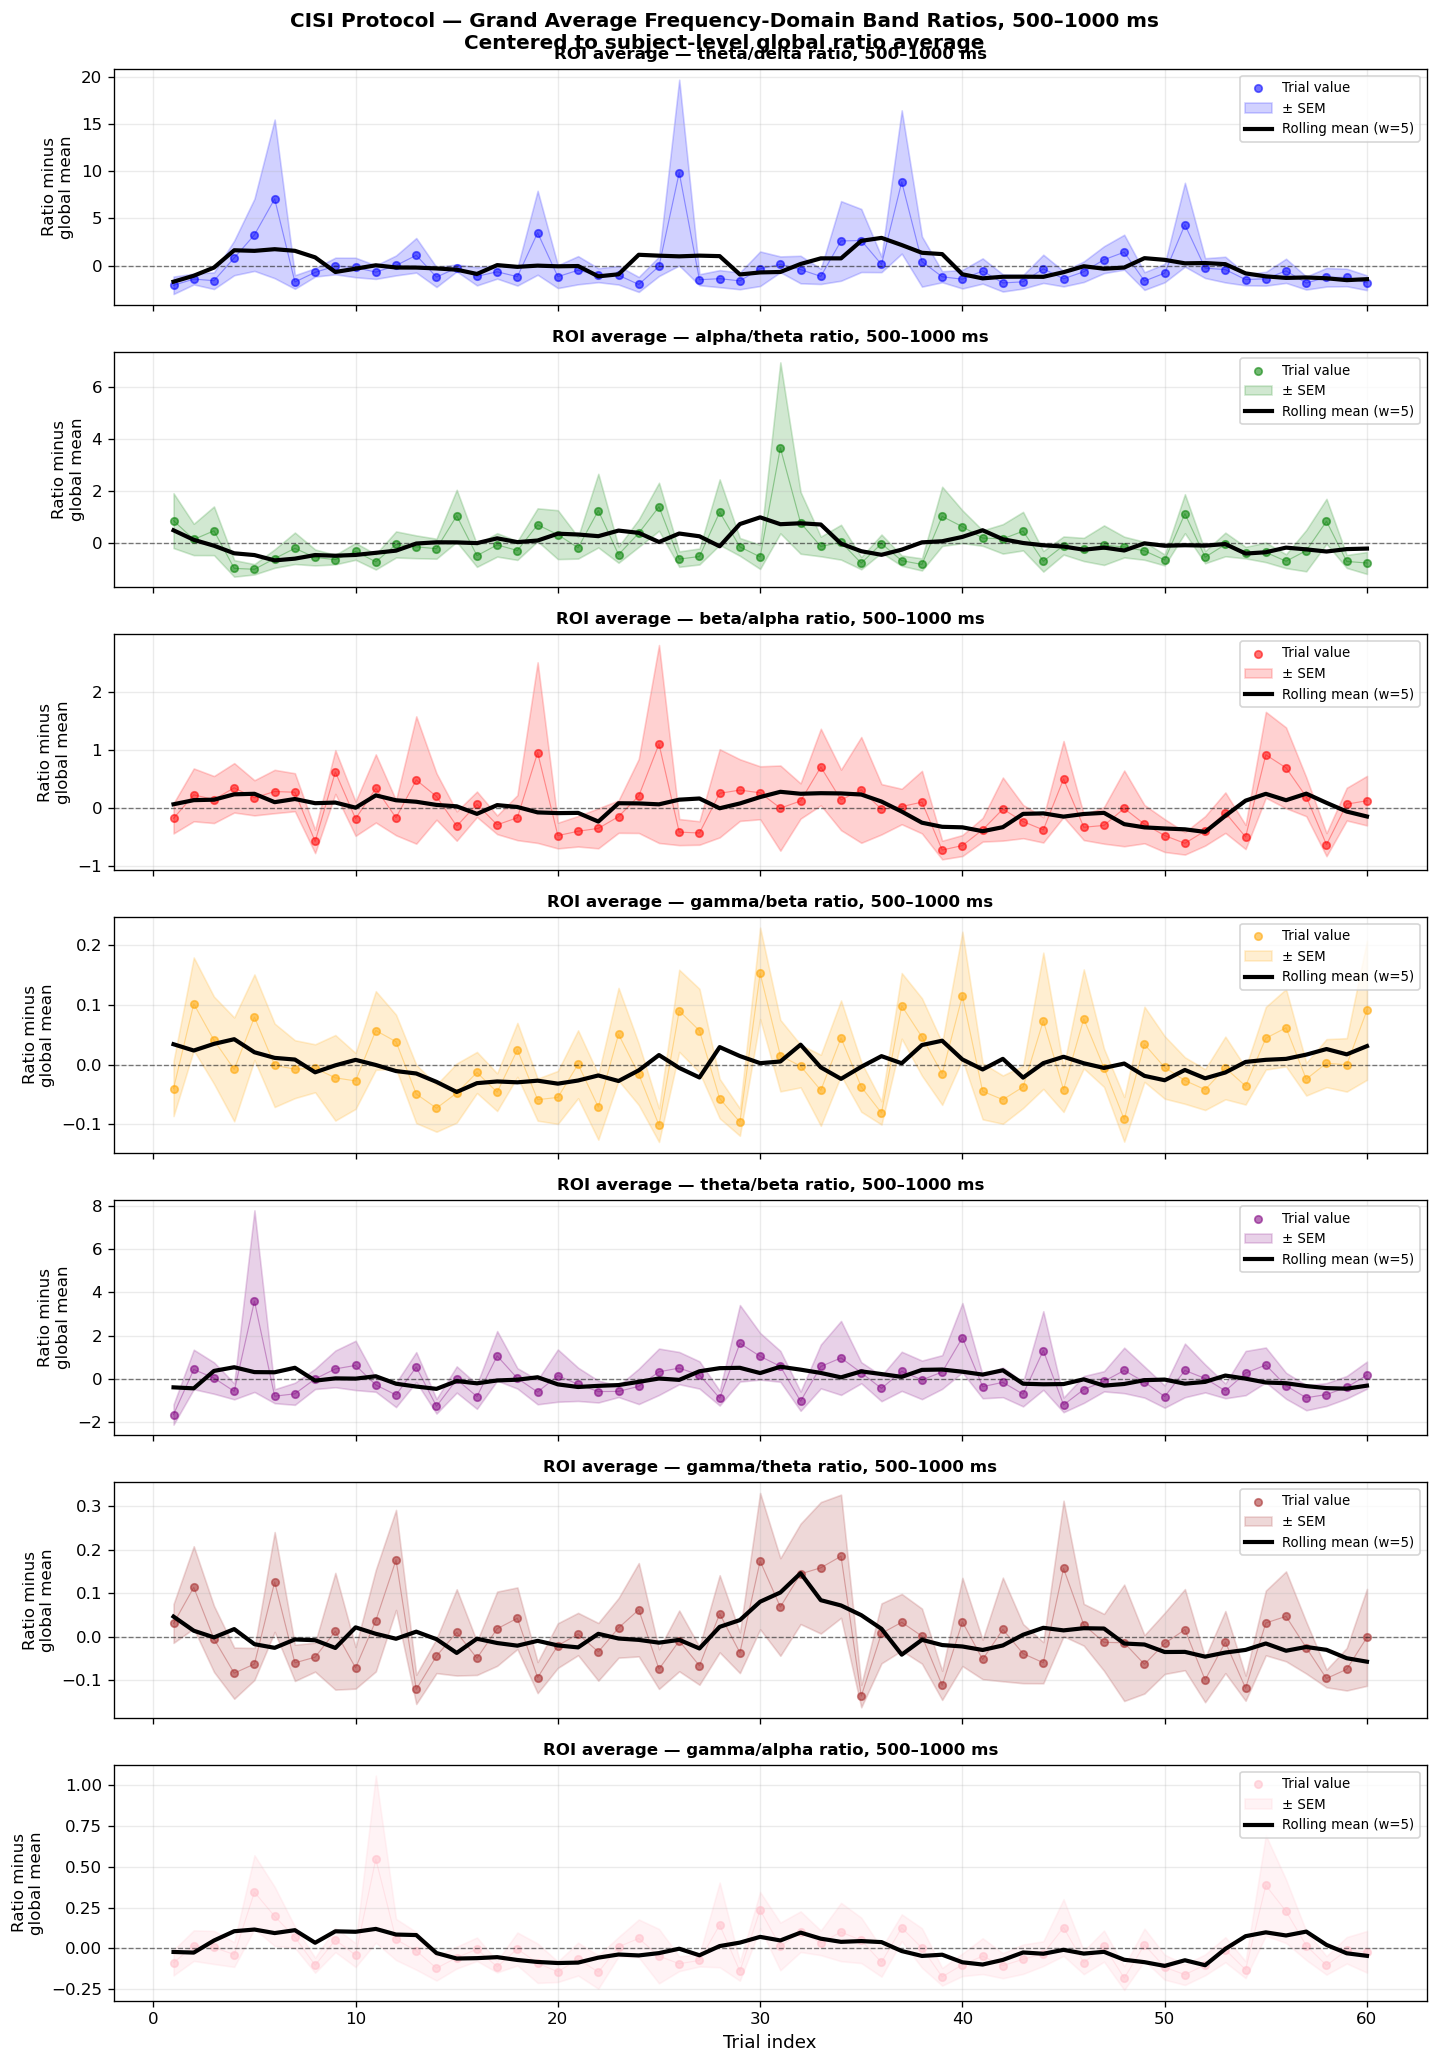

Figure saved: CISI_band_ratios_500_1000_global_mean_centered.png


In [7]:

# ------------------------------------------------------------
# BAND RATIOS — 500–1000 ms
# ------------------------------------------------------------

ratio_results_500_1000 = compute_centered_band_ratios_for_window(
    window_name="500_1000_ms",
    tmin=0.5,
    tmax=1.0
)

plot_centered_band_ratios(
    results=ratio_results_500_1000,
    title_label="500–1000 ms",
    save_filename="CISI_band_ratios_500_1000_global_mean_centered.png"
)


In [8]:

# ------------------------------------------------------------
# OPTIONAL: INSPECT ONE SUBJECT'S RAW AND CENTERED RATIOS
# ------------------------------------------------------------

# This lets you check the actual numbers for one subject.
example_subject = ratio_results_all_times["processed_subjects"][0]

print(f"Example subject: {example_subject}")

print("\nRaw ratio values, first few trials:")
display(ratio_results_all_times["all_ratio_pivots_raw"][example_subject].head())

print("\nGlobal ratio baselines subtracted:")
display(ratio_results_all_times["all_ratio_baseline_pivots"][example_subject])

print("\nCentered ratio values, first few trials:")
display(ratio_results_all_times["all_ratio_pivots_centered"][example_subject].head())


Example subject: 2

Raw ratio values, first few trials:


,theta/delta,alpha/theta,beta/alpha,gamma/beta,theta/beta,gamma/theta,gamma/alpha
trial,,,,,,,
0,1.126640,0.652949,1.465662,0.241409,1.044930,0.231029,0.353824
1,0.774980,0.852155,1.611129,0.212128,0.728368,0.291238,0.341766
2,1.116136,0.792371,1.199784,0.177477,1.051885,0.168722,0.212934
3,1.136856,0.960854,1.145908,0.189762,0.908224,0.208937,0.217450
4,0.832442,0.565177,1.445796,0.157023,1.223795,0.128308,0.227023



Global ratio baselines subtracted:


,theta/delta,alpha/theta,beta/alpha,gamma/beta,theta/beta,gamma/theta,gamma/alpha
0,1.090583,1.225626,1.047272,0.15808,0.932796,0.18687,0.168637



Centered ratio values, first few trials:


,theta/delta,alpha/theta,beta/alpha,gamma/beta,theta/beta,gamma/theta,gamma/alpha
trial,,,,,,,
0,0.036056,-0.572677,0.418389,0.083329,0.112133,0.044159,0.185187
1,-0.315603,-0.373471,0.563857,0.054048,-0.204428,0.104368,0.173129
2,0.025553,-0.433255,0.152512,0.019396,0.119088,-0.018147,0.044297
3,0.046273,-0.264772,0.098636,0.031681,-0.024573,0.022068,0.048813
4,-0.258142,-0.660449,0.398524,-0.001058,0.290998,-0.058562,0.058386


# Time-frequency band ratio graphs

This section adds the same ratio idea to the **time-frequency domain**.

Instead of graphing a ratio across trial number, these graphs show how each ratio changes across **time relative to stimulus onset**. Each subject is centered by subtracting that subject's global mean ratio across all trials and all time points.


Time-frequency ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


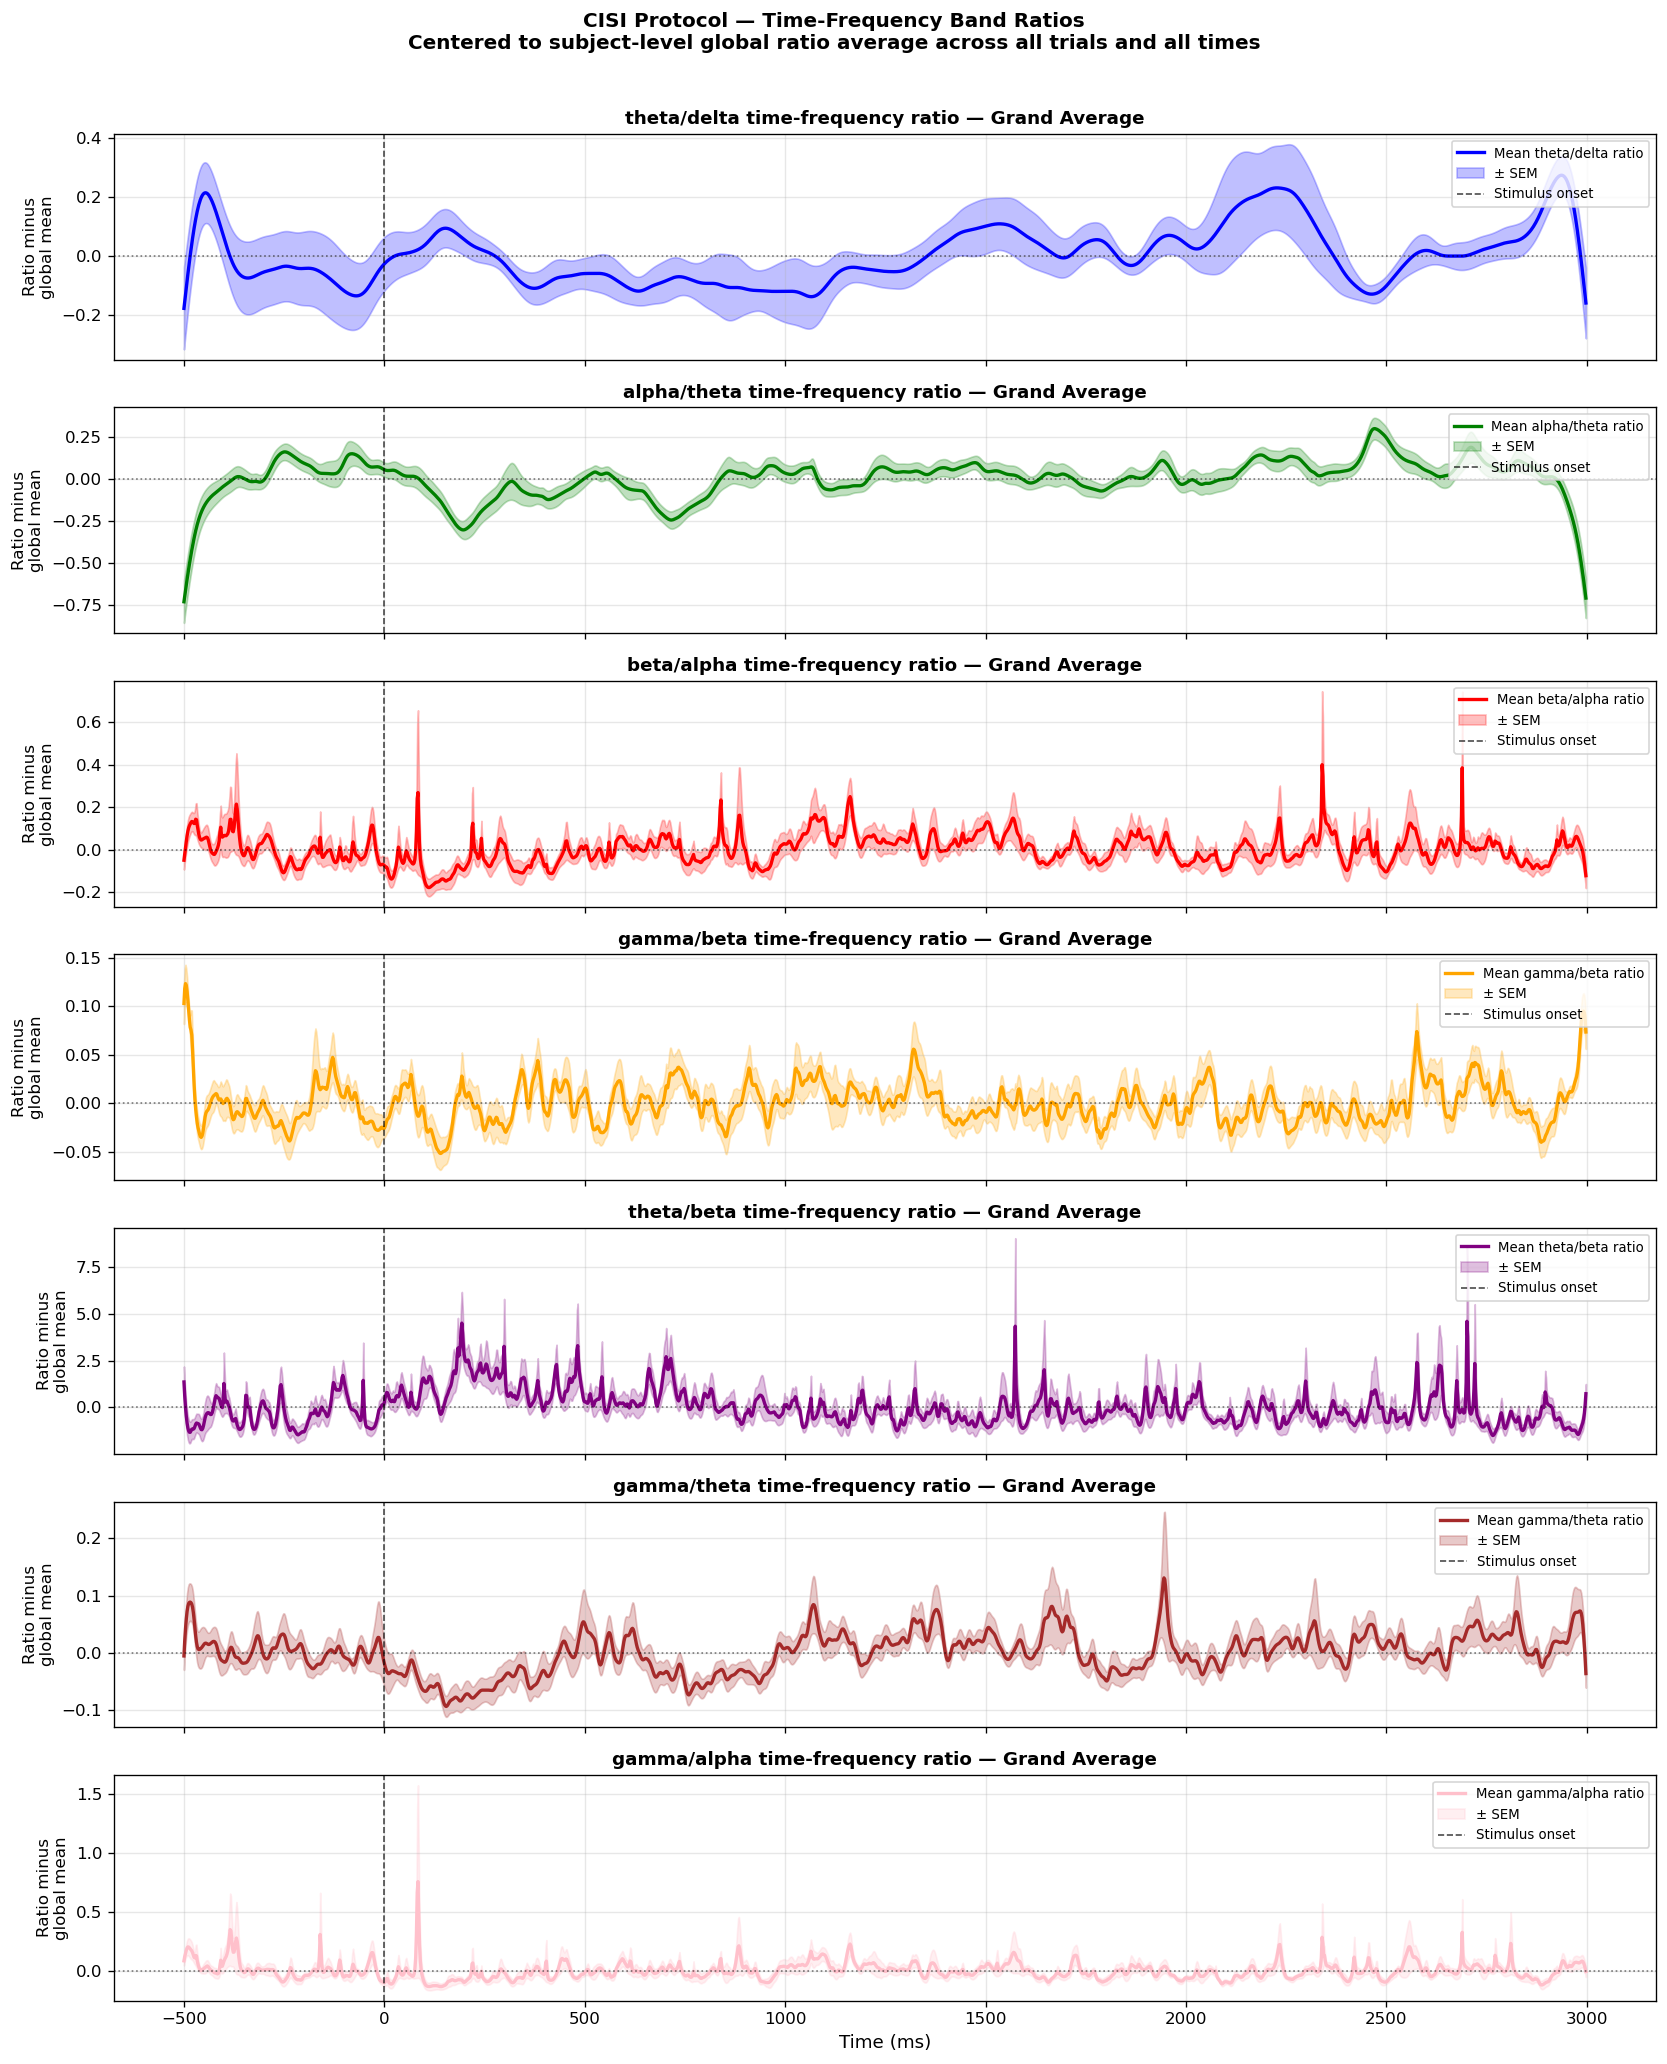

Figure saved: tf_band_ratios_CISI_global_mean_centered.png


In [9]:

# ------------------------------------------------------------
# TIME-FREQUENCY BAND RATIOS
# centered to a subject-level global mean ratio across all trials and all times
# ------------------------------------------------------------

# Import the wavelet function used to compute time-frequency power.
from mne.time_frequency import tfr_morlet

# Frequencies sampled by the time-frequency decomposition.
# This matches the method from the original time-frequency graph section.
TF_FREQS = np.logspace(np.log10(1), np.log10(45), 20)

# Number of wavelet cycles.
# This matches the original notebook's time-frequency settings.
TF_N_CYCLES = 2.0

# Frequency limits used to define the named bands.
band_limits = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 45),
}

# These dictionaries store subject-level time-frequency outputs.
tf_ratio_power_pivots_raw = {}
tf_ratio_pivots_raw = {}
tf_ratio_baseline_pivots = {}
tf_ratio_pivots_centered = {}

tf_ratio_processed_subjects = []
tf_ratio_failed_subjects = []

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load the same CISI/P1 epochs as the original notebook.
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Compute time-frequency power separately for each ROI channel.
                # average=False keeps individual trials.
                roi_channel_tfrs = []

                for ch in epochs.ch_names:
                    tfr = tfr_morlet(
                        epochs.copy().pick([ch]),
                        freqs=TF_FREQS,
                        n_cycles=TF_N_CYCLES,
                        average=False,
                        return_itc=False,
                        verbose=False
                    )

                    # tfr.data shape:
                    # (n_trials, 1 channel, n_freqs, n_times)
                    # Remove the singleton channel dimension.
                    roi_channel_tfrs.append(tfr.data[:, 0, :, :])

                # Average across ROI channels.
                # Result shape:
                # (n_trials, n_freqs, n_times)
                roi_power = np.mean(roi_channel_tfrs, axis=0)

                # Convert seconds to milliseconds for plotting.
                time_points = tfr.times * 1000

        # Store raw band-level trial x time tables here.
        subject_raw_bands = {}

        # Collapse the full frequency axis into named bands.
        for band in bands:
            fmin, fmax = band_limits[band]

            # Keep frequencies inside this band.
            freq_mask = (TF_FREQS >= fmin) & (TF_FREQS < fmax)

            if not np.any(freq_mask):
                continue

            # Average across frequencies inside the band.
            # Result shape:
            # (n_trials, n_times)
            band_power_raw = roi_power[:, freq_mask, :].mean(axis=1)

            # Convert to DataFrame:
            # rows = trials
            # columns = time points in ms
            subject_raw_bands[band] = pd.DataFrame(
                band_power_raw,
                columns=time_points
            )

        # Compute time-frequency ratios at each trial x time point.
        subject_raw_ratios = {}
        subject_centered_ratios = {}
        baseline_row = {}

        for numerator_band, denominator_band in BAND_RATIO_PAIRS:
            ratio_name = f"{numerator_band}/{denominator_band}"

            if numerator_band in subject_raw_bands and denominator_band in subject_raw_bands:

                # Ratio at each trial x time point.
                ratio_raw = subject_raw_bands[numerator_band].div(
                    subject_raw_bands[denominator_band]
                )

                # Replace infinite values just in case the denominator is zero.
                ratio_raw = ratio_raw.replace([np.inf, -np.inf], np.nan)

                # One scalar global mean ratio for this subject:
                # average over all trials and all time points.
                ratio_global_baseline = np.nanmean(ratio_raw.values)

                # Center the full trial x time map by subtracting that scalar.
                ratio_centered = ratio_raw - ratio_global_baseline

            else:
                # If one of the bands is missing, make an all-NaN table
                # with the correct trial x time shape.
                template_band = next(iter(subject_raw_bands.values()))
                ratio_raw = pd.DataFrame(
                    np.nan,
                    index=template_band.index,
                    columns=template_band.columns
                )
                ratio_global_baseline = np.nan
                ratio_centered = ratio_raw.copy()

            subject_raw_ratios[ratio_name] = ratio_raw
            subject_centered_ratios[ratio_name] = ratio_centered
            baseline_row[ratio_name] = ratio_global_baseline

        tf_ratio_power_pivots_raw[subject_id] = subject_raw_bands
        tf_ratio_pivots_raw[subject_id] = subject_raw_ratios
        tf_ratio_pivots_centered[subject_id] = subject_centered_ratios
        tf_ratio_baseline_pivots[subject_id] = pd.DataFrame(
            [baseline_row],
            columns=ratio_labels
        )

        tf_ratio_processed_subjects.append(subject_id)

    except Exception as e:
        tf_ratio_failed_subjects.append((subject_id, str(e)))

print("Time-frequency ratio subjects processed:", tf_ratio_processed_subjects)

if tf_ratio_failed_subjects:
    print("\nTime-frequency ratio failures:")
    for subject_id, err in tf_ratio_failed_subjects:
        print(f"Subject {subject_id}: {err}")


# ------------------------------------------------------------
# GRAND AVERAGE TIME-FREQUENCY RATIOS ACROSS SUBJECTS
# ------------------------------------------------------------

grand_tf_ratio = {}
grand_tf_ratio_sem = {}

for ratio_name in ratio_labels:
    ratio_subject_means = []

    for subject_id in tf_ratio_processed_subjects:
        subject_ratio_maps = tf_ratio_pivots_centered[subject_id]

        if ratio_name in subject_ratio_maps:

            # Mean across trials for this subject,
            # leaving time on the x-axis.
            subject_mean = subject_ratio_maps[ratio_name].mean(axis=0)

            ratio_subject_means.append(subject_mean.reset_index(drop=True))

    if ratio_subject_means:
        ratio_df = pd.concat(ratio_subject_means, axis=1)

        # Mean across subjects at each time point.
        grand_tf_ratio[ratio_name] = ratio_df.mean(axis=1)

        # SEM across subjects at each time point.
        grand_tf_ratio_sem[ratio_name] = ratio_df.std(axis=1) / np.sqrt(ratio_df.shape[1])


# Get time points from the first available subject and ratio.
first_subject = tf_ratio_processed_subjects[0]
first_ratio = next(
    ratio_name for ratio_name in ratio_labels
    if ratio_name in tf_ratio_pivots_centered[first_subject]
)
time_points = tf_ratio_pivots_centered[first_subject][first_ratio].columns.values


# ------------------------------------------------------------
# PLOT TIME-FREQUENCY BAND RATIOS
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(ratio_labels),
    1,
    figsize=(14, 2.5 * len(ratio_labels)),
    sharex=True
)

if len(ratio_labels) == 1:
    axes = [axes]

for i, ratio_name in enumerate(ratio_labels):
    ax = axes[i]
    color = ratio_colors[i % len(ratio_colors)]

    if ratio_name in grand_tf_ratio:
        mean_ratio = grand_tf_ratio[ratio_name].values
        errors = grand_tf_ratio_sem[ratio_name].values

        ax.plot(
            time_points,
            mean_ratio,
            color=color,
            linewidth=2,
            label=f'Mean {ratio_name} ratio'
        )

        ax.fill_between(
            time_points,
            mean_ratio - errors,
            mean_ratio + errors,
            color=color,
            alpha=0.25,
            label='± SEM'
        )

        ax.axvline(
            0,
            color='k',
            linestyle='--',
            linewidth=1,
            alpha=0.7,
            label='Stimulus onset'
        )

        ax.axhline(
            0,
            color='black',
            linestyle=':',
            linewidth=1,
            alpha=0.5
        )

    ax.set_ylabel('Ratio minus\nglobal mean', fontsize=10)

    ax.set_title(
        f'{ratio_name} time-frequency ratio — Grand Average',
        fontsize=11,
        fontweight='bold'
    )

    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)

fig.suptitle(
    'CISI Protocol — Time-Frequency Band Ratios\n'
    'Centered to subject-level global ratio average across all trials and all times',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('tf_band_ratios_CISI_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: tf_band_ratios_CISI_global_mean_centered.png")


# Optional inspection for time-frequency ratios

This optional cell lets you inspect one subject's raw and centered time-frequency ratio values.


In [10]:

# ------------------------------------------------------------
# OPTIONAL: INSPECT ONE SUBJECT'S TIME-FREQUENCY RATIOS
# ------------------------------------------------------------

example_subject_tf = tf_ratio_processed_subjects[0]
example_ratio_tf = ratio_labels[0]

print(f"Example subject: {example_subject_tf}")
print(f"Example ratio: {example_ratio_tf}")

print("\nRaw time-frequency ratio values, first few trials and first few time points:")
display(tf_ratio_pivots_raw[example_subject_tf][example_ratio_tf].iloc[:5, :5])

print("\nGlobal ratio baseline that was subtracted:")
display(tf_ratio_baseline_pivots[example_subject_tf])

print("\nCentered time-frequency ratio values, first few trials and first few time points:")
display(tf_ratio_pivots_centered[example_subject_tf][example_ratio_tf].iloc[:5, :5])


Example subject: 2
Example ratio: theta/delta

Raw time-frequency ratio values, first few trials and first few time points:


,-500.000000,-498.046875,-496.093750,-494.140625,-492.187500
0,0.367012,0.379406,0.391178,0.402194,0.412325
1,0.020838,0.020458,0.020203,0.020091,0.020140
2,1.875782,1.932992,1.987834,2.040029,2.089327
3,0.345625,0.330449,0.314552,0.298118,0.281337
4,0.400993,0.404875,0.408190,0.410987,0.413327



Global ratio baseline that was subtracted:


,theta/delta,alpha/theta,beta/alpha,gamma/beta,theta/beta,gamma/theta,gamma/alpha
0,0.72672,1.419407,1.003482,0.398515,5.45585,0.358075,0.482402



Centered time-frequency ratio values, first few trials and first few time points:


,-500.000000,-498.046875,-496.093750,-494.140625,-492.187500
0,-0.359708,-0.347313,-0.335542,-0.324526,-0.314395
1,-0.705882,-0.706262,-0.706516,-0.706628,-0.706580
2,1.149062,1.206272,1.261114,1.313309,1.362607
3,-0.381095,-0.396271,-0.412168,-0.428601,-0.445383
4,-0.325727,-0.321845,-0.318530,-0.315732,-0.313392
